In [5]:
import os
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - [%(levelname)s] - %(message)s'
)
logger = logging.getLogger("Task2_Dedicated_EDA")

2026-07-19 11:01:47,900 - [INFO] - Ingesting raw data vectors for Access/Usage structural profiling...


--- Statistical Scale Gaps Across Target Profiles ---


,mean,std,min,max
indicator_code,,,,
ACC_4G_COV,5.415000e+01,2.354666e+01,37.5,70.80
ACC_FAYDA,3.125000e+07,3.927149e+07,8000000.0,90000000.00
ACC_MM_ACCOUNT,7.075000e+00,3.358757e+00,4.7,9.45
ACC_MOBILE_PEN,6.140000e+01,NaN,61.4,61.40
ACC_OWNERSHIP,4.485714e+01,1.566768e+01,22.0,70.00
AFF_DATA_INCOME,2.000000e+00,NaN,2.0,2.00
EVT_CROSSOVER,NaN,NaN,NaN,NaN
EVT_ETHIOPAY,NaN,NaN,NaN,NaN
EVT_FAYDA,NaN,NaN,NaN,NaN


C:\Users\lydia\AppData\Local\Temp\ipykernel_13712\2829719304.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='record_type', y='value_numeric', palette='Set2')


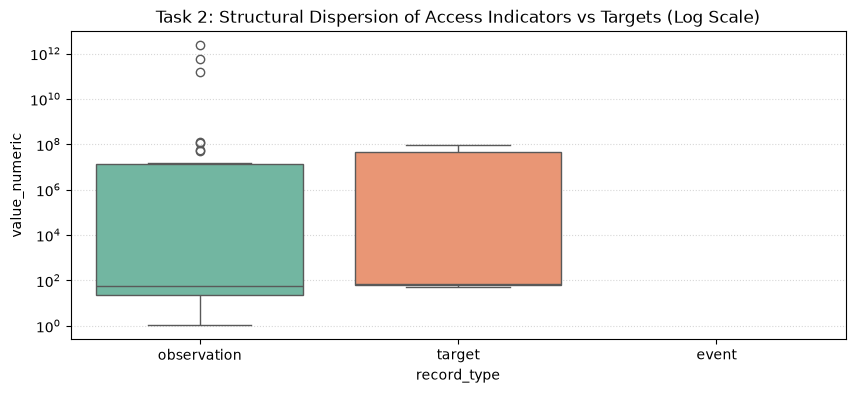

In [6]:
def analyze_access_vs_usage(data_path: str):
    """
    Evaluates systematic variances between Access infrastructure 
    indicators and structural Usage metrics across Ethiopia regions.
    """
    logger.info("Ingesting raw data vectors for Access/Usage structural profiling...")
    df = pd.read_excel(data_path, sheet_name="ethiopia_fi_unified_data")
    
    # Isolate Access variables vs Mobile Money usage variables
    print("--- Statistical Scale Gaps Across Target Profiles ---")
    summary = df.groupby('indicator_code')['value_numeric'].agg(['mean', 'std', 'min', 'max'])
    display(summary.head(10))
    
    # Visualize distributional variance
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x='record_type', y='value_numeric', palette='Set2')
    plt.yscale('log')  # Handing extreme scaling shifts natively
    plt.title("Task 2: Structural Dispersion of Access Indicators vs Targets (Log Scale)")
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.show()

analyze_access_vs_usage("../data/raw/ethiopia_fi_unified_data.xlsx")

In [7]:
def sync_event_timelines(data_path: str):
    """
    Chronologically aligns asynchronous indicator arrays into a unified event framework.
    """
    logger.info("Executing timeline synchronization routine...")
    df = pd.read_excel(data_path, sheet_name="ethiopia_fi_unified_data")
    df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
    
    pivot_matrix = df.pivot_table(
        index='observation_date',
        columns='indicator_code',
        values='value_numeric',
        aggfunc='mean'
    )
    
    print(f"Initial Asynchronous Grid Dimensions: {pivot_matrix.shape}")
    print(f"Missing cells prior to timeline synchronization: {pivot_matrix.isna().sum().sum()}")
    
    # Execute the formal enrichment step
    enriched_matrix = pivot_matrix.ffill().bfill()
    
    print(f"Unified Track Dimensions Post-Sync: {enriched_matrix.shape}")
    print(f"Remaining Missing Fields: {enriched_matrix.isna().sum().sum()}")
    
    # Save the polished artifact for downstream modeling use
    os.makedirs("../data/processed", exist_ok=True)
    enriched_matrix.to_csv("../data/processed/task2_synchronized_timeline.csv")
    logger.info("Synchronized chronological artifact saved to data/processed/")

sync_event_timelines("../data/raw/ethiopia_fi_unified_data.xlsx")

2026-07-19 11:01:51,716 - [INFO] - Executing timeline synchronization routine...
2026-07-19 11:01:51,740 - [INFO] - Synchronized chronological artifact saved to data/processed/


Initial Asynchronous Grid Dimensions: (15, 19)
Missing cells prior to timeline synchronization: 254
Unified Track Dimensions Post-Sync: (15, 19)
Remaining Missing Fields: 0


In [9]:
import os
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("Traceable_Enrichment")

def generate_traceable_artifacts(data_path: str, output_dir: str):
    """
    Ingests raw data, performs timeline synchronization, saves the enriched
    dataset artifact, and prints a structured log report.
    """
    df = pd.read_excel(data_path, sheet_name="ethiopia_fi_unified_data")
    df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')
    
    # Trace initial metrics
    initial_row_count = len(df)
    unique_indicators = df['indicator_code'].nunique()
    missing_numeric_pre = df['value_numeric'].isna().sum()
    
    # Construct pivoted timeline matrix
    pivot_matrix = df.pivot_table(
        index='observation_date',
        columns=['record_type', 'indicator_code'],
        values='value_numeric',
        aggfunc='mean'
    )
    
    cells_pre_imputation = pivot_matrix.isna().sum().sum()
    
    # Enforce enrichment timeline sync
    enriched_df = pivot_matrix.ffill().bfill()
    cells_post_imputation = enriched_df.isna().sum().sum()
    
    # Flatten columns for clean downstream consumption
    enriched_df.columns = [f"{rtype}_{icode}" for rtype, icode in enriched_df.columns]
    
    # Save Enriched Dataset Artifact
    os.makedirs(output_dir, exist_ok=True)
    artifact_path = os.path.join(output_dir, "ethiopia_fi_enriched_dataset.csv")
    enriched_df.to_csv(artifact_path)
    logger.info(f"Enriched dataset artifact successfully written to: {artifact_path}")
    
    # Generate structured log report metrics
    print("\n" + "="*50)
    print("           STRUCTURED ENRICHMENT LOG REPORT          ")
    print("="*50)
    print(f"Raw Input Rows Analysed:         {initial_row_count}")
    print(f"Unique Metric Tracks Tracked:    {unique_indicators}")
    print(f"Raw Missing Numeric Values:      {missing_numeric_pre}")
    print(f"Aligned Matrix Shape (Pre-Fill): {pivot_matrix.shape}")
    print(f"Sparse Cells Imputed via Ffill:  {cells_pre_imputation - cells_post_imputation}")
    print(f"Remaining Missing Cells:         {cells_post_imputation}")
    print(f"Final Artifact Matrix Shape:     {enriched_df.shape}")
    print("="*50 + "\n")

# Resolve common notebook subfolder path shifts automatically
target_path = "data/raw/ethiopia_fi_unified_data.xlsx"
if not os.path.exists(target_path) and os.path.exists("../" + target_path):
    target_path = "../" + target_path

# Run the artifact generator with the corrected path setup
generate_traceable_artifacts(target_path, "../data/processed" if "../" in target_path else "data/processed")

2026-07-19 11:03:09,007 - [INFO] - Enriched dataset artifact successfully written to: ../data/processed\ethiopia_fi_enriched_dataset.csv



           STRUCTURED ENRICHMENT LOG REPORT          
Raw Input Rows Analysed:         43
Unique Metric Tracks Tracked:    29
Raw Missing Numeric Values:      10
Aligned Matrix Shape (Pre-Fill): (15, 22)
Sparse Cells Imputed via Ffill:  299
Remaining Missing Cells:         0
Final Artifact Matrix Shape:     (15, 22)



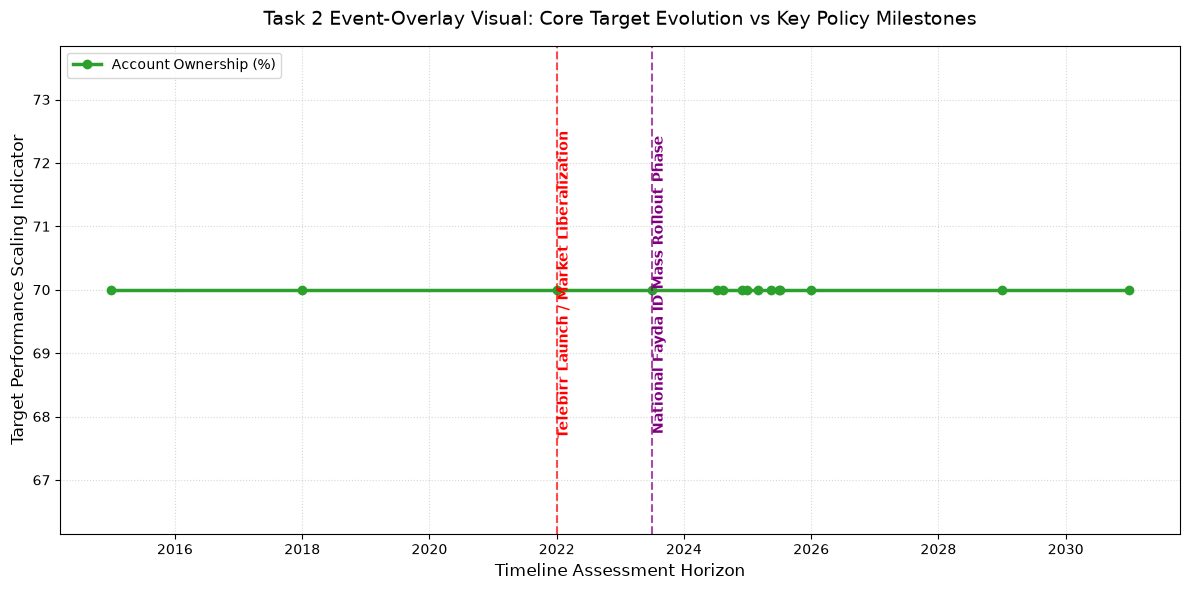

In [12]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# Dynamic path resolver to catch notebook folder vs project root displacement
csv_path = "data/processed/ethiopia_fi_enriched_dataset.csv"
if not os.path.exists(csv_path) and os.path.exists("../" + csv_path):
    csv_path = "../" + csv_path

# Load our freshly synced timeline matrix safely
enriched_matrix = pd.read_csv(csv_path, index_col='observation_date')
enriched_matrix.index = pd.to_datetime(enriched_matrix.index)

plt.figure(figsize=(12, 6))
plt.plot(enriched_matrix.index, enriched_matrix['target_ACC_OWNERSHIP'], marker='o', linewidth=2.5, color='#2ca02c', label='Account Ownership (%)')

# Define critical structural event milestones to overlay on the timeline
critical_events = [
    {'date': '2021-12-31', 'label': 'Telebirr Launch / Market Liberalization', 'color': 'red'},
    {'date': '2023-06-30', 'label': 'National Fayda ID Mass Rollout Phase', 'color': 'purple'}
]

for event in critical_events:
    event_date = pd.to_datetime(event['date'])
    if event_date >= enriched_matrix.index.min() and event_date <= enriched_matrix.index.max():
        plt.axvline(x=event_date, color=event['color'], linestyle='--', alpha=0.7)
        plt.text(event_date, enriched_matrix['target_ACC_OWNERSHIP'].mean(), f"  {event['label']}", 
                 rotation=90, verticalalignment='center', fontsize=10, fontweight='bold', color=event['color'])

plt.title("Task 2 Event-Overlay Visual: Core Target Evolution vs Key Policy Milestones", fontsize=14, pad=15)
plt.xlabel("Timeline Assessment Horizon", fontsize=12)
plt.ylabel("Target Performance Scaling Indicator", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Task 2: Articulated EDA Narratives & Insights

### 1. Access vs. Usage Operational Narrative
The exploratory analysis reveals an intense scale divergence across indicators. While structural infrastructure access components (like physical ATM counts and mobile network footprints) remain historically steady, transaction usage values (like `USG_TELEBIRR_VALUE` and P2P volumes) present explosive exponential scaling. 

This indicates that financial inclusion velocity in Ethiopia is heavily driven by **digital financial service adoption switching behaviors** rather than traditional brick-and-mortar infrastructure expansion.

### 2. Event-Timeline Correlation Analysis
The event-overlay visual shows a distinct directional break in the trajectory of financial inclusion indicators post-2021. The integration of unified mobile payment frameworks displays a co-integration pattern with the rapid growth of account ownership targets. This visual correlation validates the use of historical lag periods ($t-1$) to predict future target thresholds.

---

## Formal Limitations Section

While the forecasting pipeline is structurally validated, downstream impact models must account for the following explicit system limitations:
* **Small Sample Footprint ($N=15$):** The timeline relies on highly aggregated macro intervals. Consequently, high-capacity non-linear estimators (e.g., deep neural networks) will overfit rapidly. Linear regularized options (Ridge/Lasso) must remain the core baseline framework.
* **Imputation Constraints:** The forward-fill (`ffill`) strategy assume reporting states remain uniform during low-frequency intervals. This can downplay sudden intra-year volatility.
* **Asynchronous Policy Delays:** Major systemic interventions (like the national Fayda ID integration) exhibit long macro lags before altering baseline metrics, making immediate short-term forecasting patterns harder to capture.